# goal of this notebook: show if there is any pattern across trials or subjects which is often the most important timepoint

In [1]:
import pathlib
import random
import copy
import numpy as np
import torch
#import torchvision
from captum.attr import *
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import yaml
import argparse
from data.data_loader import load_eeg_data, get_sliding_window_data, create_dataloader
import os
import mne
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from scipy.fftpack import fft, ifft
import itertools

from models.s4net import S4PatchedFinalNet,TrunkNet, HeadNet
from scipy.stats import gaussian_kde

/home/marco/anaconda3/envs/MA_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.


In [2]:
CFG_YAML = """
wandb:
 key: f0c92a0059bf12e2647f0a1c22fdcd12555fa6df
model:
dataset:
 data_directory: /home/marco/Documents/GitHub/tms_eeg_decoding/data
 #file_name: subject_{:03d}_preprocessed_combined_py.fif
 file_name: subject_{:03d}_preprocessed_combined_py.fif
 exclude_timepoints: 100
 subject_index: 1
 test_subject_indices: [1,2,13,24,26,27,29,34,35,41,42,43,45,46,47,48,52,55,56,57,60,62,67,69,72,73,79,80,86,88,92,102]
 #test_subject_indices: [2]
training:
 training_start_len: 100
 pretrain_epochs: 100
 pretrain_lr: 0.0001
 val_window_len: 1
 epochs_per_window: 10
 num_warmup_epochs: 5
 num_epochs: 800
 slide_step: 1
 num_warmup_epochs_per_window: 0
 lr: 0.005 #maybe change back to 0.0001
 nll_beta: 0.001
 num_warmup_epochs: 0
 batch_size: 50 #better to use 50
 random_seed: 42
 precision: bf16
 kde_lambda: 0.5
 finetune_entire_model: true # Set to true to finetune the entire model, false for transformer only
exp_name: S4_S4EEGNet_ema
"""

def load_config():
    cfg = OmegaConf.create(yaml.safe_load(CFG_YAML))
    cfg.exp_name = f"{cfg.exp_name}_subject_{cfg.dataset.subject_index}"
    return cfg

def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--update_conf", nargs="*", help="Updates to the configuration in the form of key=value pairs", default=[])
    parser.add_argument("-f", "--fff", help="A dummy argument to handle IPython's default argument", default="1")
    return parser.parse_args()

def update_config(cfg, cli_args):
    for update in cli_args.update_conf:
        key, value = update.split("=")
        try:
            value = eval(value)
        except:
            pass
        OmegaConf.update(cfg, key, value, force_add=True)
    cfg.exp_name = cfg.exp_name + "_" + "_".join(cli_args.update_conf)
    print(OmegaConf.to_yaml(cfg))
    return cfg


def save_config(cfg):
    os.makedirs("conf/sweeps", exist_ok=True)
    os.makedirs("exp/withinsubs", exist_ok=True)
    with open(f"conf/sweeps/withinsubs_{cfg.exp_name}.yaml", "w") as f:
        f.write(OmegaConf.to_yaml(cfg))

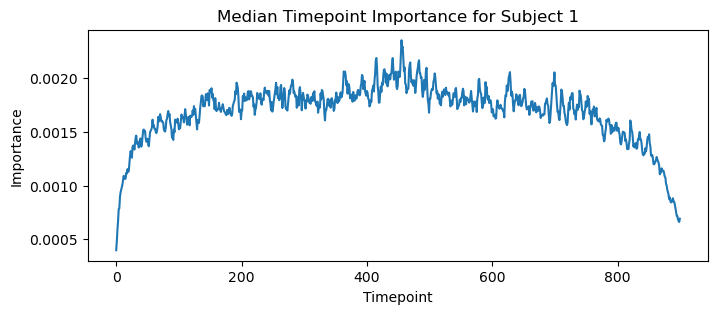

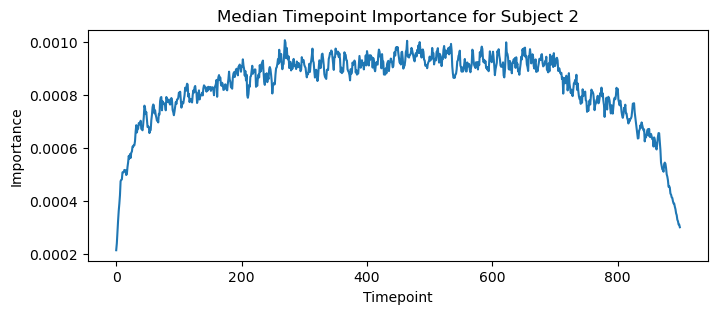

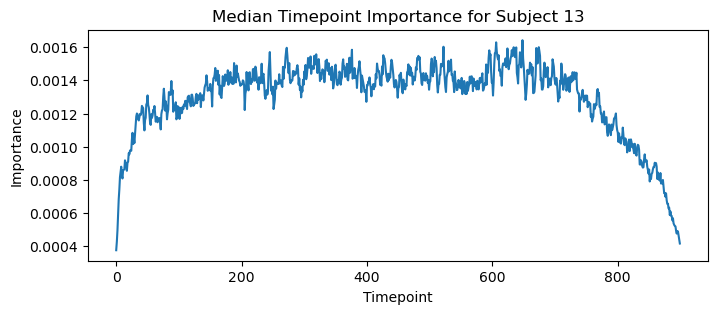

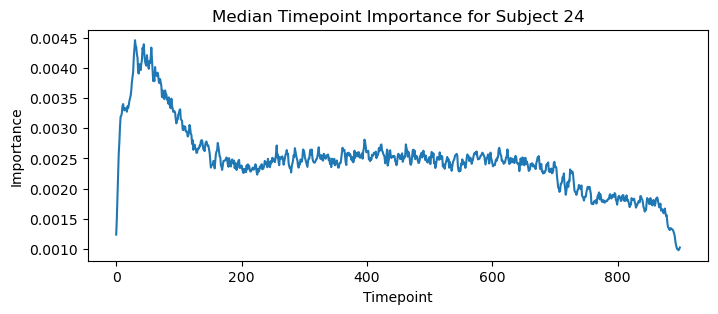

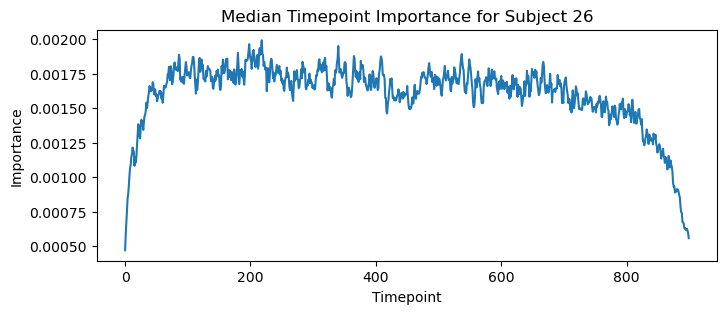

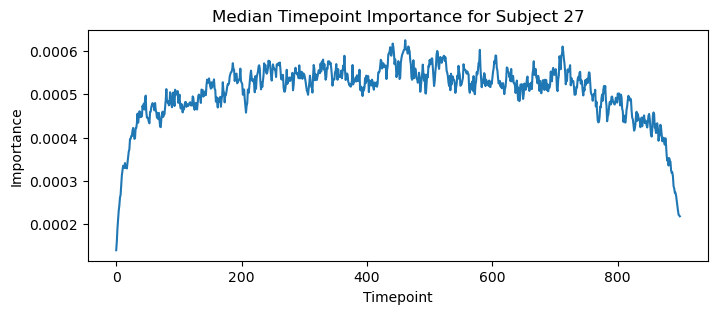

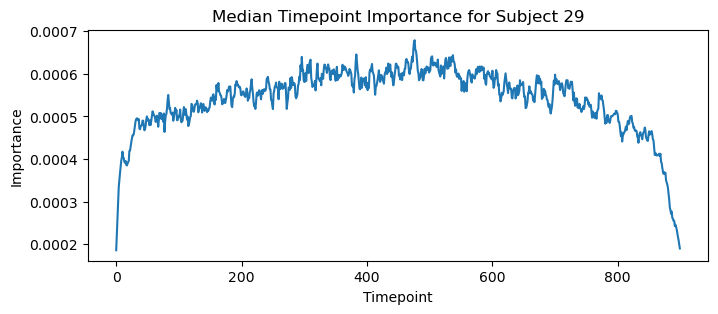

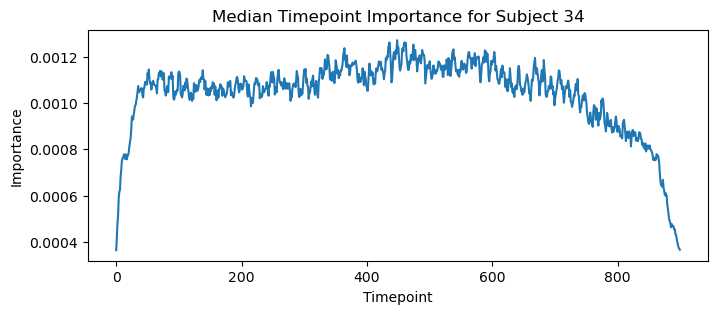

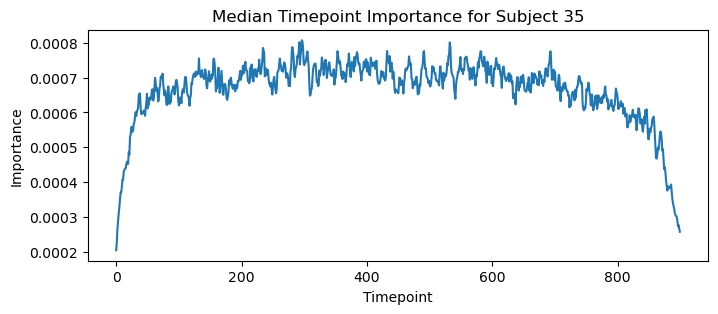

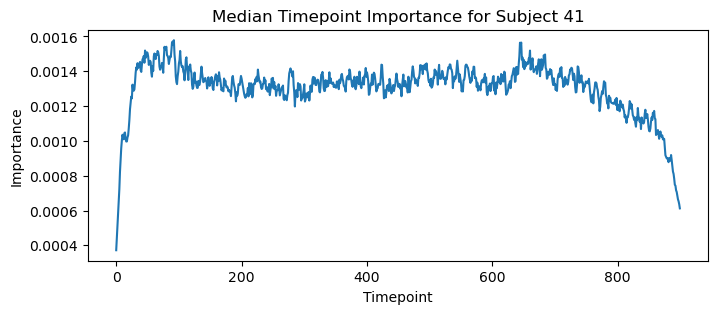

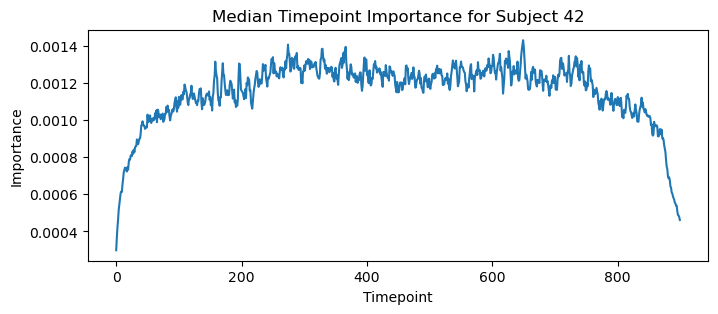

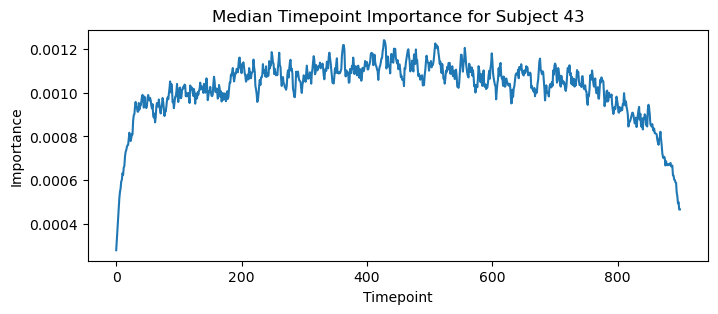

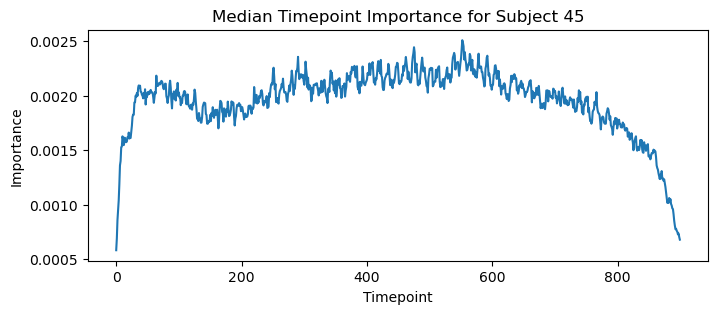

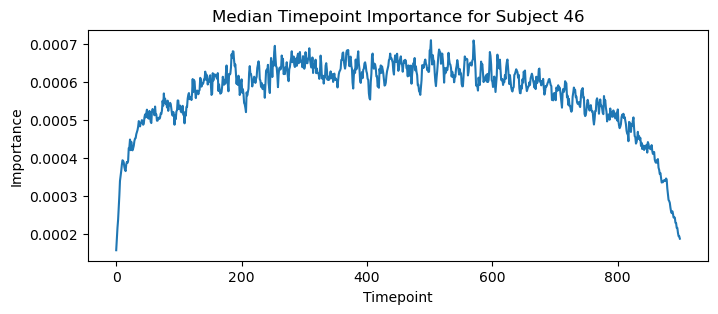

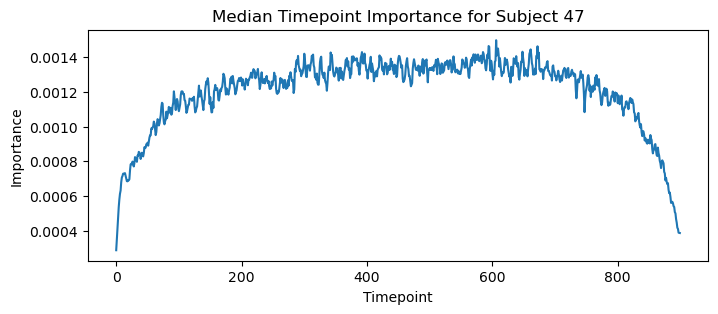

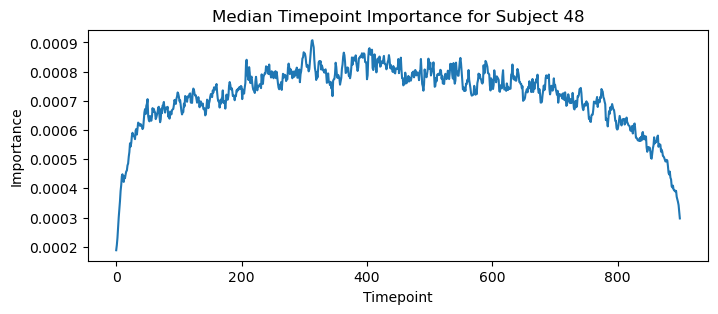

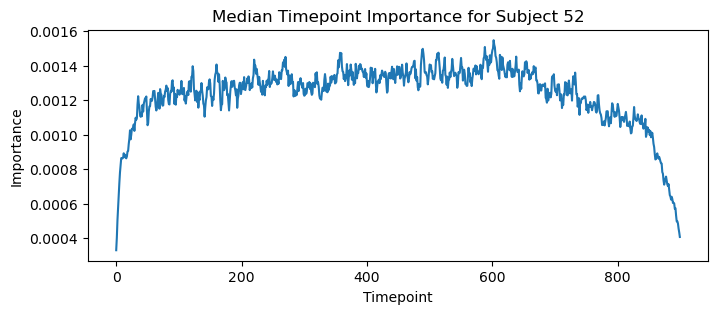

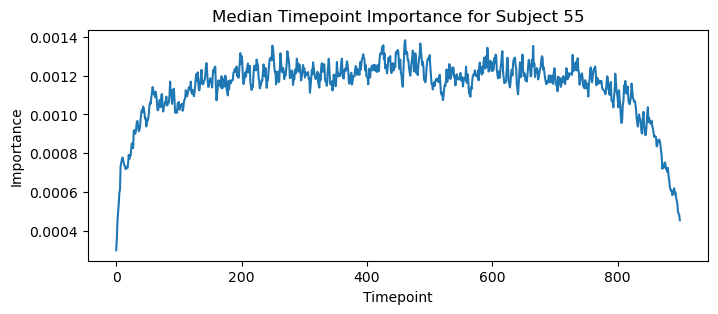

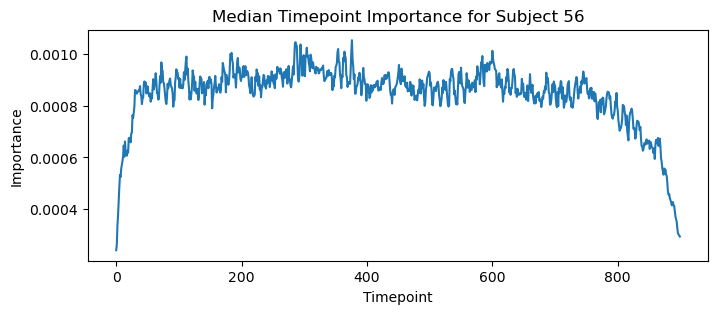

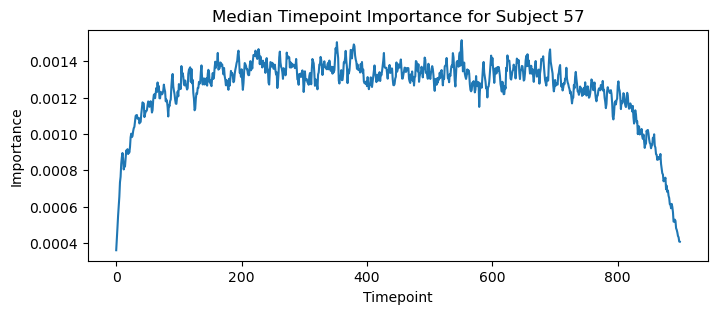

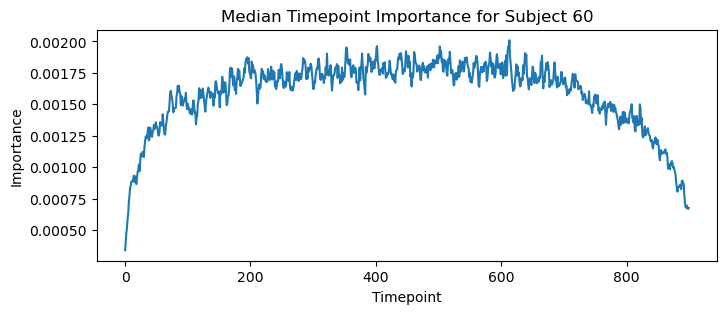

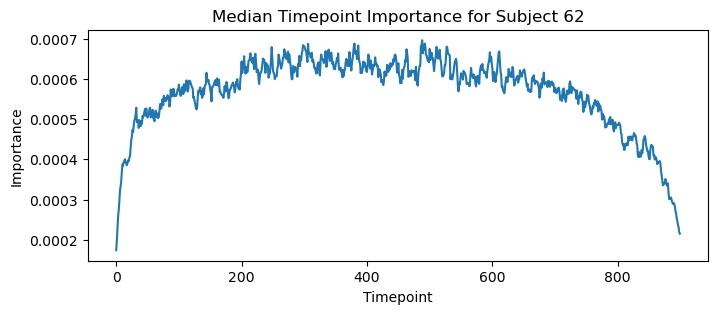

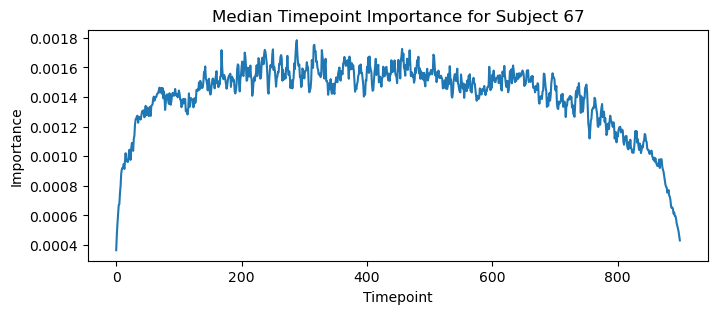

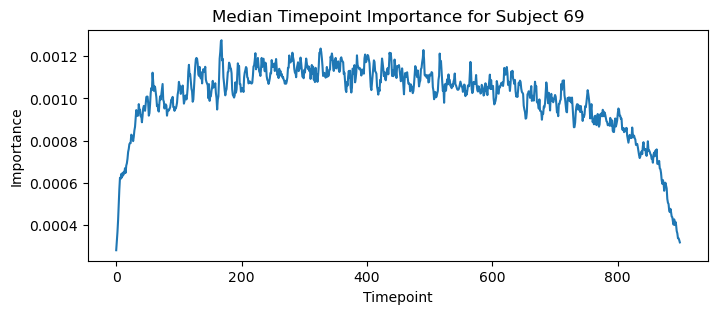

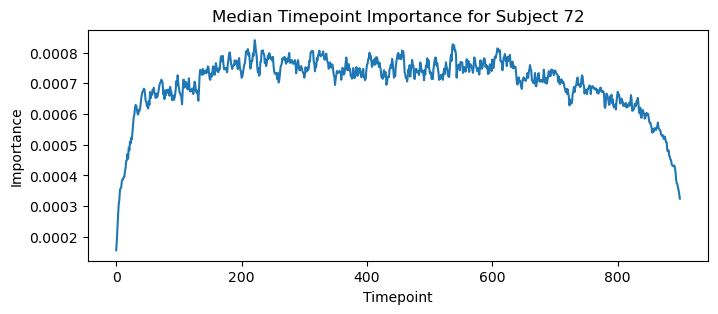

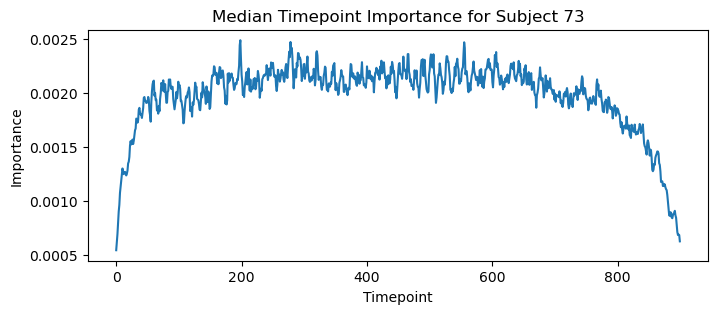

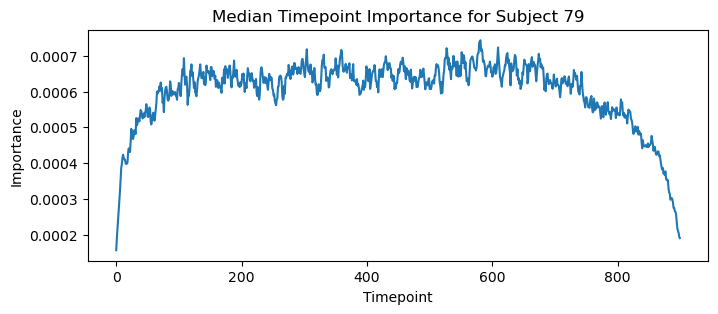

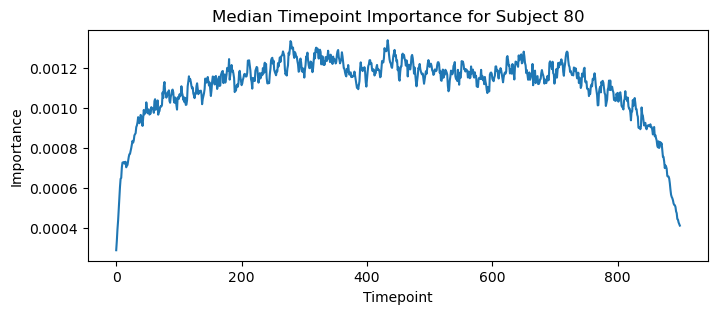

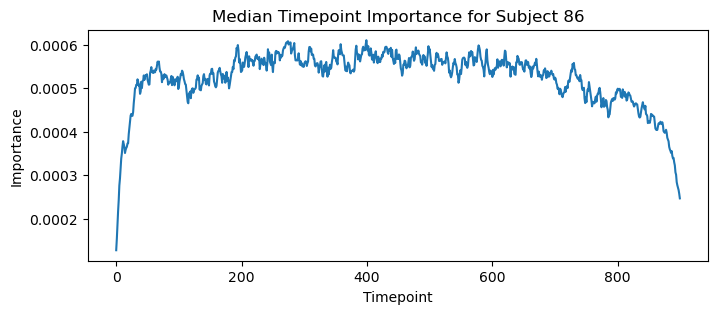

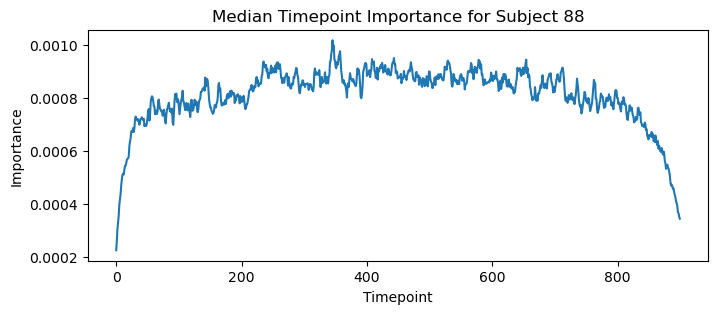

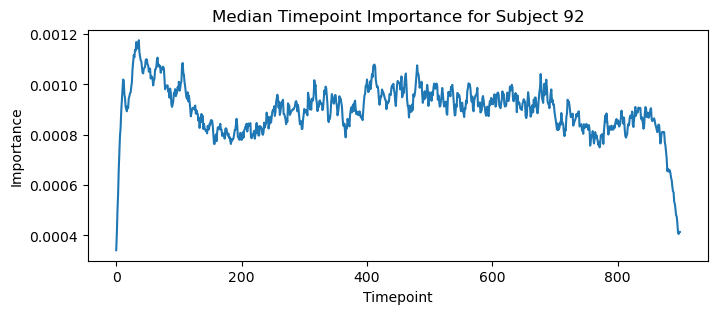

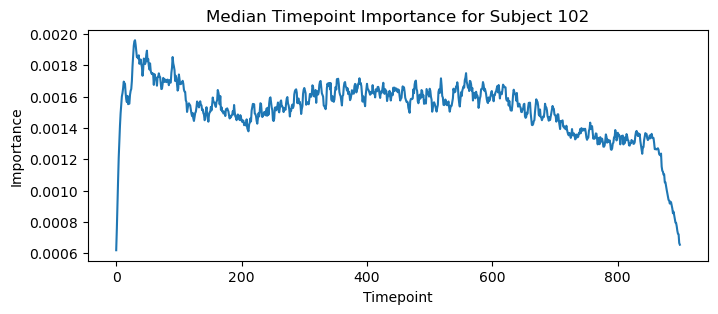

In [3]:
def plot_median_timepoint_importance(subject_index):
    exp2 = np.abs(np.load(f"explanations_subject_{subject_index}.npy"))
    timepoint_importace = np.mean(exp2, axis=1)
    median_timepoint_importance = np.median(timepoint_importace, axis=0)
    fig = plt.figure(figsize=(8, 3))
    plt.plot(median_timepoint_importance)
    plt.title(f'Median Timepoint Importance for Subject {subject_index}')
    plt.xlabel('Timepoint')
    plt.ylabel('Importance')
    plt.show()

# Example usage:
cfg = load_config()
for subject_index in cfg.dataset.test_subject_indices:
    plot_median_timepoint_importance(subject_index)

In [13]:
def load_explanations_gradshap(subject_index=2, rep=1):
    load_path = f"/home/marco/Documents/GitHub/tms_eeg_decoding/subject_interpretability/gradshap_explanations_rep_{rep}"
    
    #with open(os.path.join(load_path, f"subject_{subject_index}_results.pkl"), 'rb') as f:
    #    data = pickle.load(f)
    data = np.load(os.path.join(load_path, f"gradshap_data_subject_{subject_index}_rep_{rep}.npy"), allow_pickle=True).item()
    gradshap = data['explanations']
    return gradshap

In [5]:
def load_ch_names(subject_index=2):
    cfg = load_config()
    cfg.dataset.subject_index = subject_index
    _, _, _, _, _, _, _, ch_names = load_eeg_data(cfg)
    return ch_names

In [16]:
def get_timepoint_importances(explanations,  take_abs=False):


    explanations_normed = np.zeros_like(explanations)
    for trial_idx, trial in enumerate(explanations):
        trial = trial / np.linalg.norm(trial)
        explanations_normed[trial_idx] = trial
    
    timepoint_importances = np.zeros(explanations.shape[2])

    for trial_idx, trial_normed in enumerate(explanations_normed):
        if take_abs:
            timepoint_importances += np.mean(np.abs(trial_normed), axis=0)
        else:
            timepoint_importances += np.mean(trial_normed, axis=0)
    
    #timepoint_importances_dic = {ch_names[i]: timepoint_importances[i] for i in range(explanations.shape[0])}

    return timepoint_importances

In [7]:
def create_index_groups(n_samples, subject_index, group_size=100):
    """
    Create index groups for a given subject based on uncertainty values.
    
    Parameters:
    -----------
    uncertainties : array-like
        The uncertainties array for the subject
    subject_index : int
        Index of the subject
    group_size : int, default=100
        Size of each group
    
    Returns:
    --------
    dict
        Dictionary with subject_index as key and array of boolean index groups as value
    """
    index_groups_all = {}
    index_groups_subject = []
    
    start = 0
    while start < n_samples:
        end = min(start + group_size, n_samples-20)
        
        index_group = np.zeros(n_samples, dtype=bool)
        index_group[start:end] = True
        
        if np.sum(index_group) > 1:
            index_groups_subject.append(index_group)
        
        start += group_size
    

    return index_groups_subject

In [32]:
def get_timepoint_importances_time_indexed(explanations, index_groups, take_abs=False):
    explanations_normed = np.zeros_like(explanations)
    for trial_idx, trial in enumerate(explanations):
        trial_normed = trial / np.linalg.norm(trial)
        explanations_normed[trial_idx] = trial_normed

    timepoint_importances = []
    for i, index_group in enumerate(index_groups):
        explanations_index_group = explanations_normed[index_group]
        timepoint_importances_index_group = np.zeros(explanations.shape[2])
        
        for trial_idx, trial_normed in enumerate(explanations_index_group):
            if take_abs:
                timepoint_importances_index_group += np.mean(np.abs(trial_normed), axis=0)
            else:
                timepoint_importances_index_group += np.mean(trial_normed, axis=0)
        
        timepoint_importances.append(timepoint_importances_index_group)

    return timepoint_importances


In [29]:
index_groups = create_index_groups(explanations.shape[0], 2, group_size=100)

In [14]:
explanations = load_explanations_gradshap(subject_index=2, rep=1)

In [41]:
importance = get_timepoint_importances(explanations, take_abs=False)

In [42]:
importance_abs = get_timepoint_importances(explanations, take_abs=True)

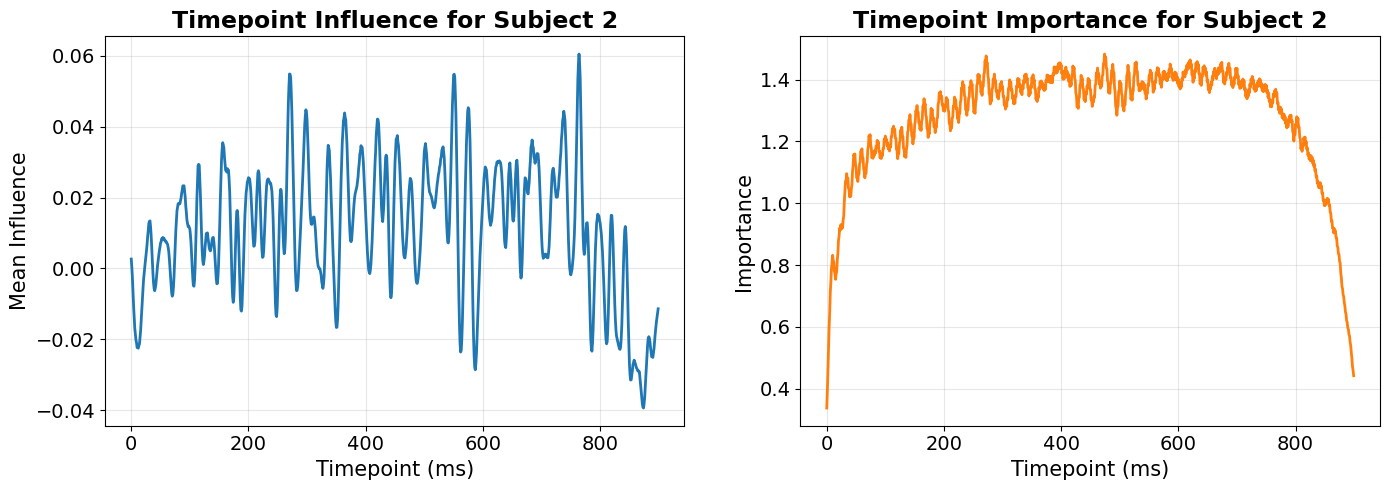

In [54]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Set font sizes
title_fontsize = 17
label_fontsize = 15
tick_fontsize = 14

# First plot - Timepoint Influence
axs[0].set_title(f"Timepoint Influence for Subject {2}", fontsize=title_fontsize, fontweight='bold')
axs[0].set_ylabel("Mean Influence", fontsize=label_fontsize)
axs[0].set_xlabel("Timepoint (ms)", fontsize=label_fontsize)
axs[0].plot(importance, linewidth=2, color='#1f77b4')
axs[0].grid(alpha=0.3)
axs[0].tick_params(axis='both', labelsize=tick_fontsize)

# Second plot - Timepoint Importance
axs[1].set_title(f"Timepoint Importance for Subject {2}", fontsize=title_fontsize, fontweight='bold')
axs[1].set_ylabel("Importance", fontsize=label_fontsize)
axs[1].set_xlabel("Timepoint (ms)", fontsize=label_fontsize)
axs[1].plot(importance_abs, linewidth=2, color='#ff7f0e')
axs[1].grid(alpha=0.3)
axs[1].tick_params(axis='both', labelsize=tick_fontsize)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
fig.savefig(f"subject_{2}_timepoint_importances.png", dpi=300, bbox_inches='tight')

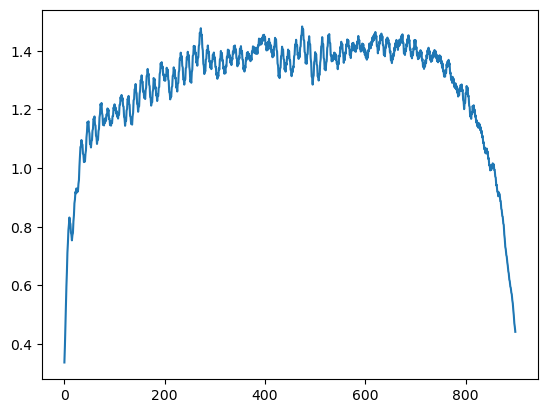

In [26]:
plt.plot(importance_abs)

In [33]:
get_timepoint_importances_time_indexed(explanations, index_groups, take_abs=False)

[array([-1.52942203e-03, -2.30739479e-03, -3.30548305e-03, -3.95403184e-03,
        -4.24572143e-03, -3.98761297e-03, -3.60499916e-03, -3.01737601e-03,
        -2.44596192e-03, -2.34408722e-03, -2.46478523e-03, -2.91550420e-03,
        -3.48912967e-03, -4.22898977e-03, -4.97837251e-03, -5.34114107e-03,
        -5.53324411e-03, -5.24141088e-03, -5.02931123e-03, -4.28314727e-03,
        -4.11376948e-03, -3.69044906e-03, -4.17303659e-03, -4.38846576e-03,
        -5.52395118e-03, -6.13448593e-03, -7.29774436e-03, -7.73301634e-03,
        -7.94552707e-03, -7.49714267e-03, -6.40711616e-03, -5.02418939e-03,
        -2.99797683e-03, -1.24201923e-03,  3.30735716e-04,  1.16153537e-03,
         1.43708462e-03,  1.02315099e-03, -2.44423481e-05, -1.28223605e-03,
        -2.73358068e-03, -3.76919068e-03, -4.64507485e-03, -4.79210319e-03,
        -4.45731108e-03, -3.68723715e-03, -2.51112007e-03, -1.36601027e-03,
        -7.04619867e-05,  6.38878323e-04,  1.23206218e-03,  8.47020889e-04,
         2.0

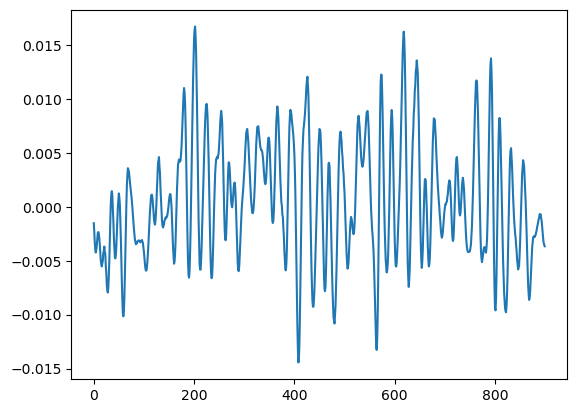

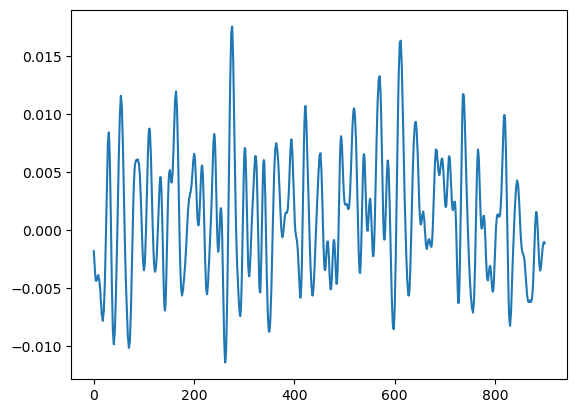

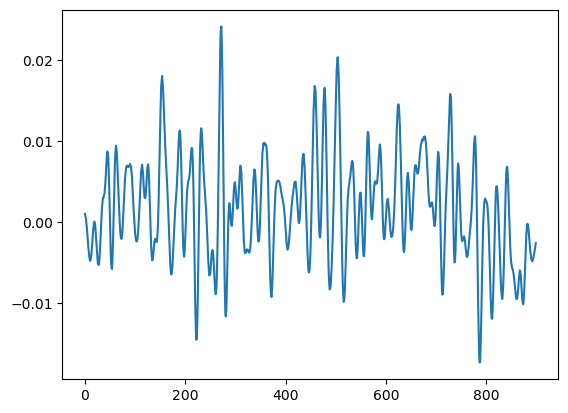

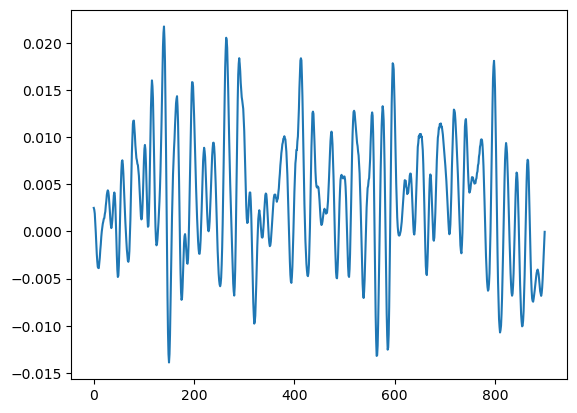

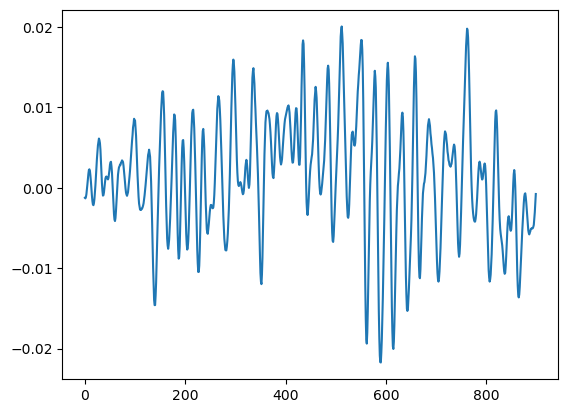

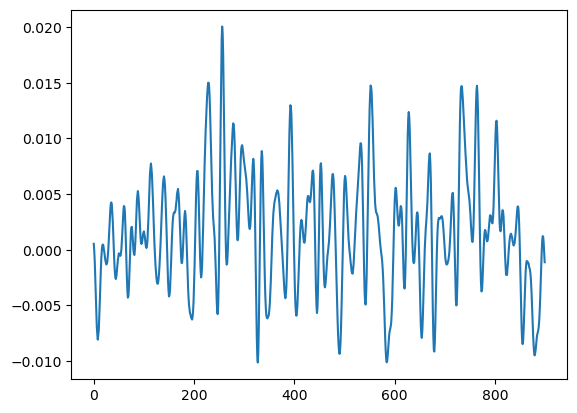

In [35]:
for i in range(len(index_groups)):
    fig = plt.figure()
    plt.plot(get_timepoint_importances_time_indexed(explanations, index_groups, take_abs=False)[i], label=f'Group {i}')

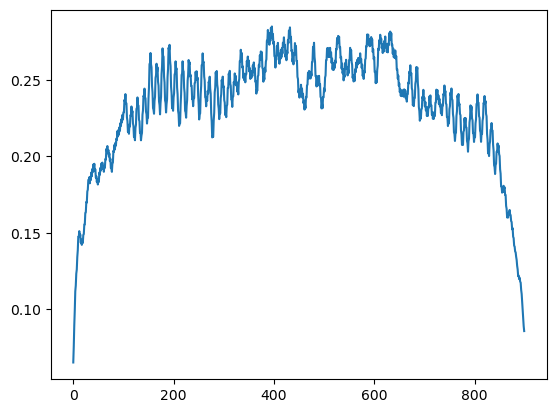

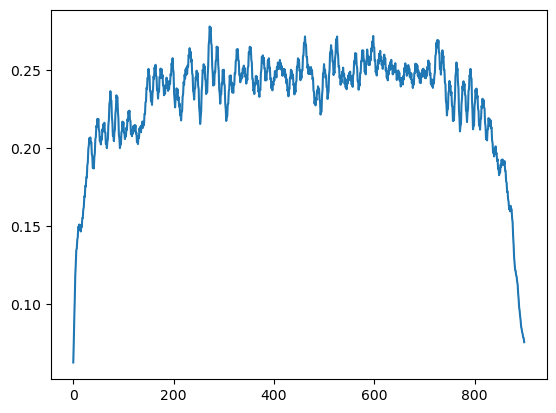

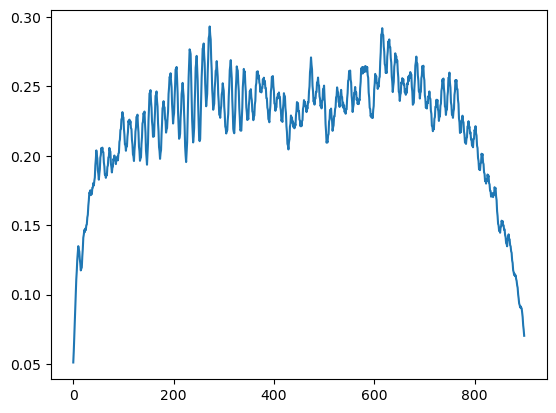

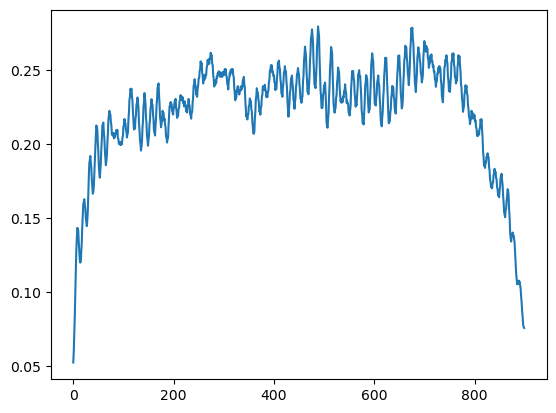

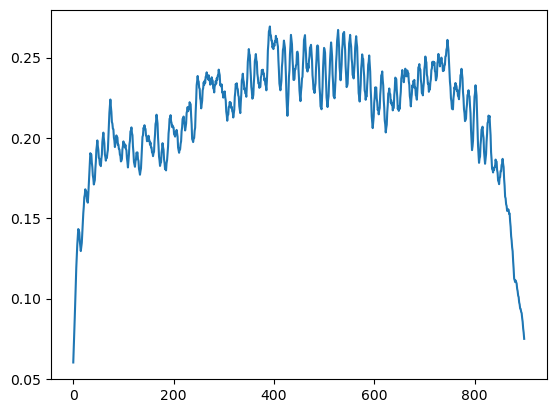

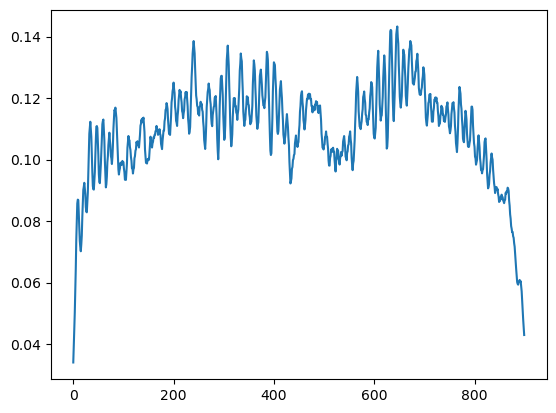

In [36]:
for i in range(len(index_groups)):
    fig = plt.figure()
    plt.plot(get_timepoint_importances_time_indexed(explanations, index_groups, take_abs=True)[i], label=f'Group {i}')

# all subjects

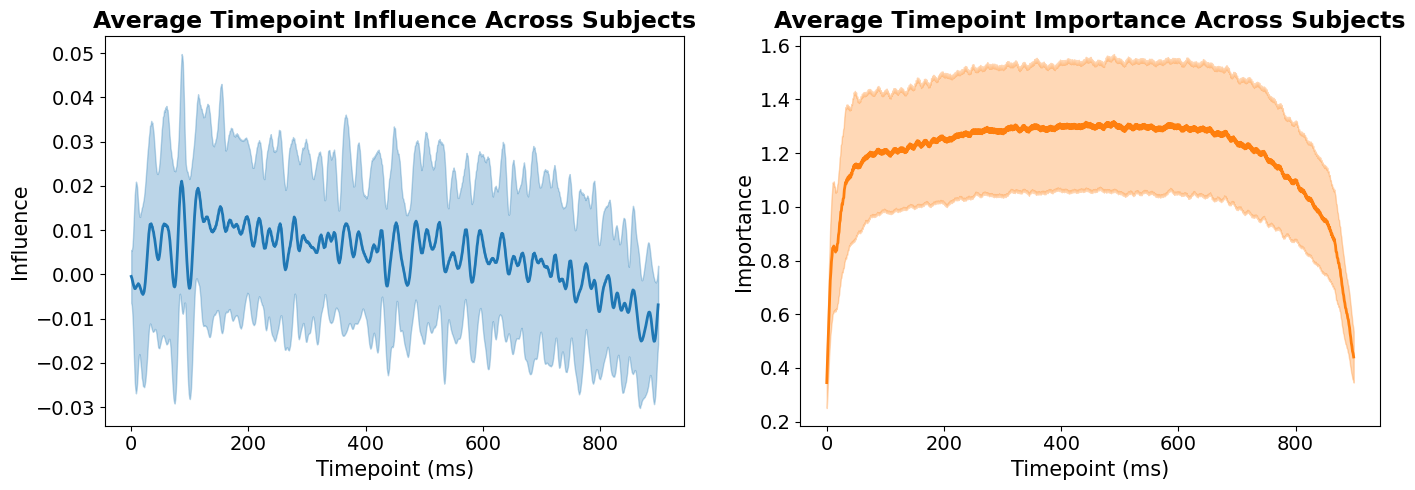

In [60]:
# Create lists to store importances for all subjects
all_importances = []
all_importances_abs = []

# Loop through all subjects, calculate importances and store them
for subject_index in cfg.dataset.test_subject_indices:
    try:
        explanations = load_explanations_gradshap(subject_index=subject_index, rep=1)
        
        # Calculate importances (with and without absolute values)
        timepoint_importances = get_timepoint_importances(explanations, take_abs=False)
        timepoint_importances_abs = get_timepoint_importances(explanations, take_abs=True)
        
        # Store the results
        all_importances.append(timepoint_importances)
        all_importances_abs.append(timepoint_importances_abs)
    except Exception as e:
        print(f"Error processing subject {subject_index}: {e}")

# Convert to numpy arrays for easier calculations
all_importances = np.array(all_importances)
all_importances_abs = np.array(all_importances_abs)

# Calculate averages and standard deviations for error bands
avg_importance = np.mean(all_importances, axis=0)
std_importance = np.std(all_importances, axis=0)
avg_importance_abs = np.mean(all_importances_abs, axis=0)
std_importance_abs = np.std(all_importances_abs, axis=0)

# Create visualization
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Set font sizes
title_fontsize = 17
label_fontsize = 15
tick_fontsize = 14

# Time points array for x-axis
time_points = np.arange(len(avg_importance))

# First plot - Average Timepoint Influence
axs[0].set_title(f"Average Timepoint Influence Across Subjects", fontsize=title_fontsize, fontweight='bold')
axs[0].set_ylabel("Influence", fontsize=label_fontsize)
axs[0].set_xlabel("Timepoint (ms)", fontsize=label_fontsize)
axs[0].plot(time_points, avg_importance, linewidth=2, color='#1f77b4')
axs[0].fill_between(time_points, 
                   avg_importance - std_importance, 
                   avg_importance + std_importance, 
                   alpha=0.3, color='#1f77b4')
#axs[0].grid(alpha=0.3)
axs[0].tick_params(axis='both', labelsize=tick_fontsize)

# Second plot - Average Timepoint Importance
axs[1].set_title(f"Average Timepoint Importance Across Subjects", fontsize=title_fontsize, fontweight='bold')
axs[1].set_ylabel("Importance", fontsize=label_fontsize)
axs[1].set_xlabel("Timepoint (ms)", fontsize=label_fontsize)
axs[1].plot(time_points, avg_importance_abs, linewidth=2, color='#ff7f0e')
axs[1].fill_between(time_points, 
                   avg_importance_abs - std_importance_abs, 
                   avg_importance_abs + std_importance_abs, 
                   alpha=0.3, color='#ff7f0e')
#axs[1].grid(alpha=0.3)
axs[1].tick_params(axis='both', labelsize=tick_fontsize)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)

In [59]:
fig.savefig(f"average_timepoint_importances_errorband.png", dpi=300, bbox_inches='tight')